# Classical Machine Learning for Amazon Fake Review Detection

This notebook builds a classical machine learning pipeline for fake review detection using the processed labeled Amazon review dataset.

We will compare three supervised baselines, evaluate them consistently, and save the best artifacts for later reuse.

## Imports

In [14]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from scipy.sparse import csr_matrix, hstack
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (10, 6)

## Load Dataset

Loaded dataset from: /content/Review-Guardian/data/processed/labeled_reviews.csv
Shape: (6232, 15)


,reviewText,content_clean,rating,productASIN,is_exact_dup,is_near_dup,is_burst_day,is_unverified,rating_deviation,exclamation_count,word_count,avg_word_len,superlative_count,fake_score,pseudo_label
0,‚úçÔ∏è The COOFANDY Men's Polo Shirt is a fant...,the coofandy men's polo shirt is a fantastic b...,5.0,B0DLGB4RYH,0.0,0.0,1.0,1.0,0.000000,0,221,5.371041,0,0.350000,1
1,I love these. They look good. They fit well. T...,i love these. they look good. they fit well. t...,5.0,B0DRXF62JH,0.0,0.0,1.0,1.0,0.057143,0,51,4.078431,0,0.355714,1
2,My expectations were low -- how good could shi...,my expectations were low -- how good could shi...,4.0,B0DRXF62JH,0.0,0.0,1.0,1.0,0.228571,0,162,4.722222,0,0.372857,1
3,This 3-pack of multi-color shirts is really a ...,this 3-pack of multi-color shirts is really a ...,5.0,B0DRXF62JH,0.0,0.0,1.0,1.0,0.057143,2,82,4.804878,1,0.355714,1
4,With these three polo shirts I was very satisf...,with these three polo shirts i was very satisf...,5.0,B0DRXF62JH,0.0,0.0,1.0,1.0,0.057143,0,48,5.354167,0,0.355714,1


Data types:


,dtype
reviewText,object
content_clean,object
rating,float64
productASIN,object
is_exact_dup,float64
is_near_dup,float64
is_burst_day,float64
is_unverified,float64
rating_deviation,float64
exclamation_count,int64


Missing values per column:


,0


Pseudo label distribution:


,count
pseudo_label,
0,5479
1,753


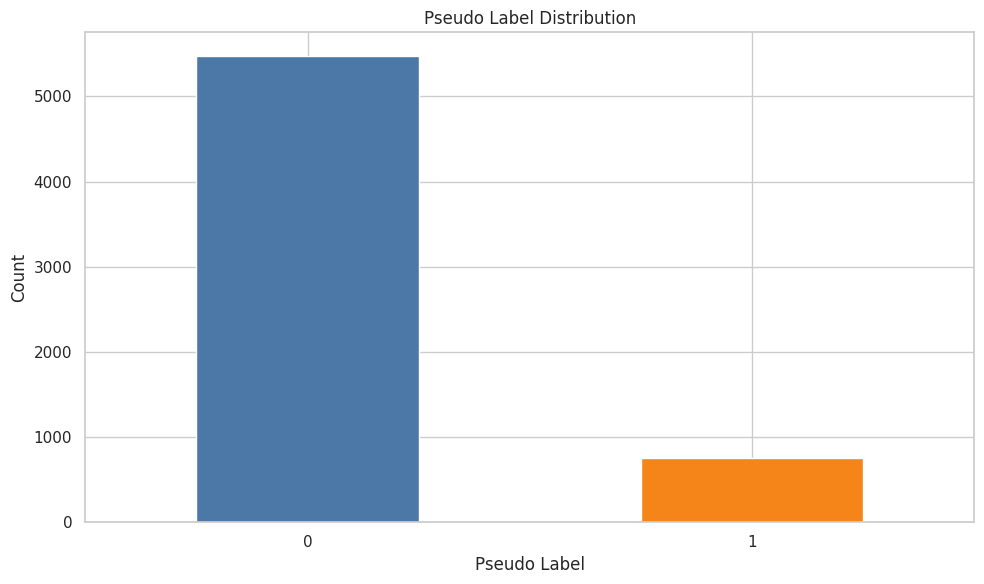

In [15]:
data_path = Path('/content/Review-Guardian/data/processed/labeled_reviews.csv')
if not data_path.exists():
    raise FileNotFoundError(f'Could not find the dataset at {data_path}. Run 02_Feature_Engineering.ipynb first.')

df = pd.read_csv(data_path)

if 'pseudo_label' not in df.columns:
    raise KeyError("Expected target column 'pseudo_label' was not found in the dataset.")

print(f'Loaded dataset from: {data_path}')
print(f'Shape: {df.shape}')
display(df.head())

print('Data types:')
display(df.dtypes.to_frame(name='dtype'))

print('Missing values per column:')
missing_counts = df.isna().sum().sort_values(ascending=False)
missing_series = missing_counts[missing_counts > 0]
display(missing_series if not missing_series.empty else pd.Series(dtype='int64'))

print('Pseudo label distribution:')
pseudo_label_counts = df['pseudo_label'].value_counts().sort_index()
display(pseudo_label_counts)

ax = pseudo_label_counts.plot(kind='bar', color=['#4c78a8', '#f58518'])
ax.set_title('Pseudo Label Distribution')
ax.set_xlabel('Pseudo Label')
ax.set_ylabel('Count')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.show()

## Data Preparation

In [16]:
target_column = 'pseudo_label'
text_column = 'content_clean'

y = df[target_column].astype(int)

# Select feature columns (excluding target and pseudo-label calculation leakage)
keep_cols = [
    'rating',
    'word_count',
    'avg_word_len',
    'exclamation_count',
    'superlative_count'
]

# Extract text and numeric feature frames prior to train/test split to prevent data leakage
df_features = df[[text_column] + keep_cols].copy()
for col in keep_cols:
    df_features[col] = df_features[col].fillna(df_features[col].median())
df_features[text_column] = df_features[text_column].fillna('').astype(str)


## Train/Test Split

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6232 entries, 0 to 6231
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   reviewText         6232 non-null   object 
 1   content_clean      6232 non-null   object 
 2   rating             6232 non-null   float64
 3   productASIN        6232 non-null   object 
 4   is_exact_dup       6232 non-null   float64
 5   is_near_dup        6232 non-null   float64
 6   is_burst_day       6232 non-null   float64
 7   is_unverified      6232 non-null   float64
 8   rating_deviation   6232 non-null   float64
 9   exclamation_count  6232 non-null   int64  
 10  word_count         6232 non-null   int64  
 11  avg_word_len       6232 non-null   float64
 12  superlative_count  6232 non-null   int64  
 13  fake_score         6232 non-null   float64
 14  pseudo_label       6232 non-null   int64  
dtypes: float64(8), int64(4), object(3)
memory usage: 730.4+ KB


In [18]:
# Perform stratified Train/Test split FIRST before fitting TF-IDF to avoid data leakage
X_train_df, X_test_df, y_train, y_test = train_test_split(df_features, y, test_size=0.2, random_state=42, stratify=y)

# Fit TfidfVectorizer STRICTLY on X_train only
tfidf = TfidfVectorizer(max_features=5000, stop_words='english')
X_train_text = tfidf.fit_transform(X_train_df[text_column])
X_test_text = tfidf.transform(X_test_df[text_column])

# Stack text and numeric features
X_train_num = csr_matrix(X_train_df[keep_cols].values)
X_test_num = csr_matrix(X_test_df[keep_cols].values)

X_train = hstack([X_train_text, X_train_num])
X_test = hstack([X_test_text, X_test_num])

print(f'Training set shape: {X_train.shape}')
print(f'Testing set shape: {X_test.shape}')

print('Training label distribution:')
display(y_train.value_counts(normalize=True).sort_index())
print('Testing label distribution:')
display(y_test.value_counts(normalize=True).sort_index())


Training set shape: (4985, 5005)
Testing set shape: (1247, 5005)
Training label distribution:


,proportion
pseudo_label,
0,0.879238
1,0.120762


Testing label distribution:


,proportion
pseudo_label,
0,0.878909
1,0.121091


## Train Three Models

In [19]:
positive_count = int((y_train == 1).sum())
negative_count = int((y_train == 0).sum())
scale_pos_weight = negative_count / positive_count if positive_count > 0 else 1.0

models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000,
        solver='liblinear',
        class_weight='balanced',
        random_state=42,
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1,
        class_weight='balanced',
    ),
    'XGBoost': XGBClassifier(
        n_estimators=300,
        learning_rate=0.1,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        random_state=42,
        n_jobs=-1,
        eval_metric='logloss',
        tree_method='hist',
        scale_pos_weight=scale_pos_weight,
    ),
}

trained_models = {}
for model_name, model in models.items():
    print(f'\nTraining {model_name}...')
    model.fit(X_train, y_train)
    trained_models[model_name] = model
    print(f'Finished training {model_name}.')


Training Logistic Regression...
Finished training Logistic Regression.

Training Random Forest...
Finished training Random Forest.

Training XGBoost...
Finished training XGBoost.


## Evaluation


Logistic Regression Evaluation
Accuracy: 0.7314
Precision: 0.2107
Recall: 0.4437
F1: 0.2857
ROC-AUC: 0.6760

Classification Report:
              precision    recall  f1-score   support

     genuine     0.9096    0.7710    0.8346      1096
        fake     0.2107    0.4437    0.2857       151

    accuracy                         0.7314      1247
   macro avg     0.5601    0.6073    0.5601      1247
weighted avg     0.8250    0.7314    0.7681      1247



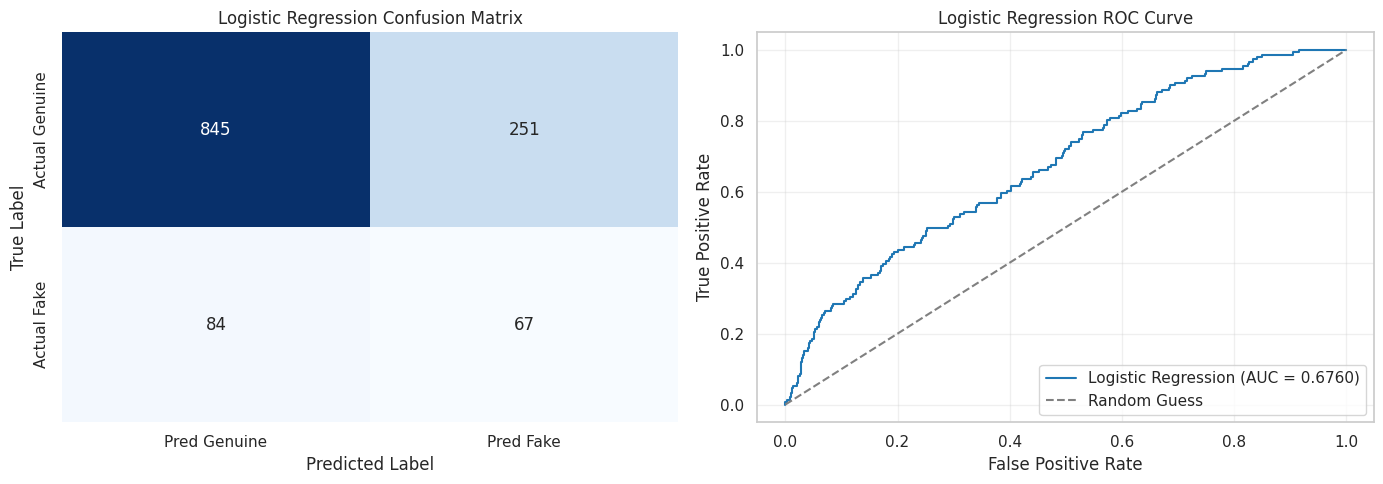


Random Forest Evaluation
Accuracy: 0.8885
Precision: 0.7500
Recall: 0.1192
F1: 0.2057
ROC-AUC: 0.7498

Classification Report:
              precision    recall  f1-score   support

     genuine     0.8913    0.9945    0.9401      1096
        fake     0.7500    0.1192    0.2057       151

    accuracy                         0.8885      1247
   macro avg     0.8206    0.5569    0.5729      1247
weighted avg     0.8741    0.8885    0.8511      1247



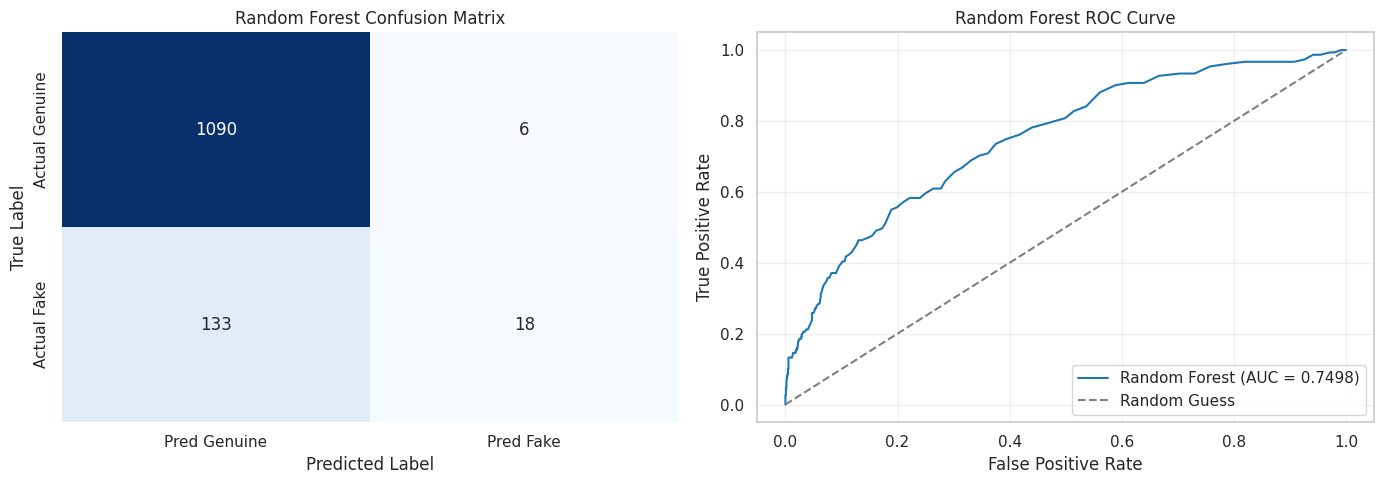


XGBoost Evaluation
Accuracy: 0.8156
Precision: 0.3015
Recall: 0.3974
F1: 0.3429
ROC-AUC: 0.7110

Classification Report:
              precision    recall  f1-score   support

     genuine     0.9132    0.8732    0.8927      1096
        fake     0.3015    0.3974    0.3429       151

    accuracy                         0.8156      1247
   macro avg     0.6073    0.6353    0.6178      1247
weighted avg     0.8391    0.8156    0.8261      1247



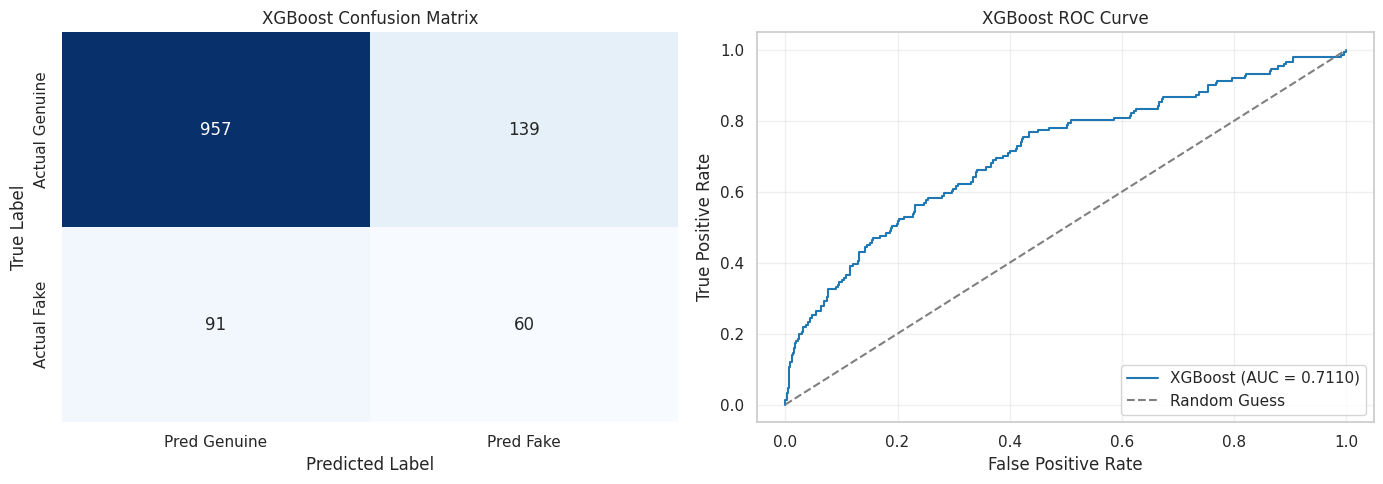

In [20]:
evaluation_results = []

def evaluate_model(model_name, model, X_eval, y_eval):
    y_pred = model.predict(X_eval)
    if hasattr(model, 'predict_proba'):
        y_score = model.predict_proba(X_eval)[:, 1]
    else:
        y_score = model.decision_function(X_eval)

    metrics_dict = {
        'Model': model_name,
        'Accuracy': accuracy_score(y_eval, y_pred),
        'Precision': precision_score(y_eval, y_pred, zero_division=0),
        'Recall': recall_score(y_eval, y_pred, zero_division=0),
        'F1': f1_score(y_eval, y_pred, zero_division=0),
        'ROC-AUC': roc_auc_score(y_eval, y_score),
    }

    separator = '=' * 80
    print(f'\n{separator}')
    print(f'{model_name} Evaluation')
    print(f'{separator}')
    for metric_name in ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']:
        print(f'{metric_name}: {metrics_dict[metric_name]:.4f}')

    print('\nClassification Report:')
    print(classification_report(
        y_eval,
        y_pred,
        target_names=['genuine', 'fake'],
        digits=4,
        zero_division=0,
    ))

    cm = confusion_matrix(y_eval, y_pred)
    fpr, tpr, _ = roc_curve(y_eval, y_score)
    roc_auc_value = metrics_dict['ROC-AUC']

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        cbar=False,
        ax=axes[0],
        xticklabels=['Pred Genuine', 'Pred Fake'],
        yticklabels=['Actual Genuine', 'Actual Fake'],
    )
    axes[0].set_title(f'{model_name} Confusion Matrix')
    axes[0].set_xlabel('Predicted Label')
    axes[0].set_ylabel('True Label')

    axes[1].plot(fpr, tpr, label=f'{model_name} (AUC = {roc_auc_value:.4f})', color='#1f77b4')
    axes[1].plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Guess')
    axes[1].set_title(f'{model_name} ROC Curve')
    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate')
    axes[1].legend(loc='lower right')
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    return metrics_dict

for model_name, model in trained_models.items():
    evaluation_results.append(evaluate_model(model_name, model, X_test, y_test))

## Model Comparison

In [21]:
comparison_df = pd.DataFrame(evaluation_results).sort_values(by=['ROC-AUC', 'F1'], ascending=False).reset_index(drop=True)
display(comparison_df)

results_dir = Path('/content/Review-Guardian/results/metrics')
results_dir.mkdir(parents=True, exist_ok=True)
comparison_path = results_dir / 'model_comparison.csv'
comparison_df.to_csv(comparison_path, index=False)
print(f'Saved model comparison table to: {comparison_path}')

best_model_name = comparison_df.iloc[0]['Model']
best_model_metrics = comparison_df.iloc[0]
print(f'\nBest model according to ROC-AUC and F1: {best_model_name}')
print(best_model_metrics.to_string())

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Random Forest,0.888532,0.750000,0.119205,0.205714,0.749789
1,XGBoost,0.815557,0.301508,0.397351,0.342857,0.710960
2,Logistic Regression,0.731355,0.210692,0.443709,0.285714,0.675968


Saved model comparison table to: /content/Review-Guardian/results/metrics/model_comparison.csv

Best model according to ROC-AUC and F1: Random Forest
Model        Random Forest
Accuracy          0.888532
Precision             0.75
Recall            0.119205
F1                0.205714
ROC-AUC           0.749789


## Save Models

In [22]:
models_dir = Path('/content/Review-Guardian/models')
models_dir.mkdir(parents=True, exist_ok=True)

for model_name, model in trained_models.items():
    filename = model_name.lower().replace(' ', '_') + '.pkl'
    model_path = models_dir / filename
    joblib.dump(model, model_path)
    print(f'Saved {model_name} to: {model_path}')
# Also save the TF-IDF vectorizer -- without it, the saved models can't
# turn new, unseen review text into the same feature format they were
# trained on, which makes them useless outside this notebook session.
vectorizer_path = models_dir / 'tfidf_vectorizer.pkl'
joblib.dump(tfidf, vectorizer_path)
print(f'Saved TF-IDF vectorizer to: {vectorizer_path}')


Saved Logistic Regression to: /content/Review-Guardian/models/logistic_regression.pkl
Saved Random Forest to: /content/Review-Guardian/models/random_forest.pkl
Saved XGBoost to: /content/Review-Guardian/models/xgboost.pkl
Saved TF-IDF vectorizer to: /content/Review-Guardian/models/tfidf_vectorizer.pkl


## Live Demo -- Test the Model on New Reviews

Reloads the saved model + vectorizer from disk (exactly like a real app would) and runs predictions on a few brand-new sentences that were never in the training data.

In [23]:
# Reload from disk to prove the saved artifacts actually work standalone --
# this is exactly what a real app / API would do: load once, predict many times.
import re
import numpy as np
import joblib
from pathlib import Path
from scipy.sparse import csr_matrix, hstack

models_dir = Path('/content/Review-Guardian/models')
loaded_vectorizer = joblib.load(models_dir / 'tfidf_vectorizer.pkl')
loaded_model = joblib.load(models_dir / 'random_forest.pkl')

def clean_text(t):
    """Same cleaning used in 01_EDA.ipynb -- must match or the vectorizer
    will see out-of-distribution text."""
    t = str(t).lower()
    t = re.sub(r'http\S+', '', t)
    t = re.sub(r'[^a-z0-9\s.,!?\'"-]', '', t)
    t = re.sub(r'\s+', ' ', t).strip()
    return t

def build_features(raw_text, score, vectorizer):
    """Recreate, for ONE new review, the exact same feature set the model
    was trained on: TF-IDF text vector + 5 numeric signals."""
    cleaned = clean_text(raw_text)
    words = cleaned.split()
    word_count = len(words)
    avg_word_len = np.mean([len(w) for w in words]) if words else 0
    exclamation_count = raw_text.count('!')
    superlative_count = len(re.findall(r'\b(best|worst|amazing|terrible|perfect|awful)\b', cleaned))

    X_text_new = vectorizer.transform([cleaned])
    X_numeric_new = csr_matrix(np.array([[score, word_count, avg_word_len,
                                           exclamation_count, superlative_count]]))
    return hstack([X_text_new, X_numeric_new])

def predict_review(raw_text, score=3, model=loaded_model, vectorizer=loaded_vectorizer):
    """
    score: the star rating (1-5) the reviewer left (maps to the 'rating'
    feature the model was trained on). Defaults to 3 (neutral) if testing
    free text with no rating -- predictions are most accurate when you
    pass the review's real star rating.
    """
    X_new = build_features(raw_text, score, vectorizer)
    pred = model.predict(X_new)[0]
    proba = model.predict_proba(X_new)[0][1]
    label = 'FAKE' if pred == 1 else 'GENUINE'
    print(f"Review: {raw_text!r}  (score={score})")
    print(f"Prediction: {label}  (fake probability: {proba:.2%})\n")
    return label, proba

# --- Live demo for the presentation ---
demo_cases = [
    ("Best app ever!!! Amazing amazing amazing, perfect in every way, buy it now!!!", 5),
    ("The checkout was a bit slow but customer service resolved my issue quickly.", 4),
    ("Terrible, worst purchase, never buying again, awful awful awful experience!!!", 1),
    ("Decent value for the price, delivery took an extra day.", 3),
]

for text, score in demo_cases:
    predict_review(text, score=score)


Review: 'Best app ever!!! Amazing amazing amazing, perfect in every way, buy it now!!!'  (score=5)
Prediction: GENUINE  (fake probability: 6.33%)

Review: 'The checkout was a bit slow but customer service resolved my issue quickly.'  (score=4)
Prediction: GENUINE  (fake probability: 18.33%)

Review: 'Terrible, worst purchase, never buying again, awful awful awful experience!!!'  (score=1)
Prediction: GENUINE  (fake probability: 14.00%)

Review: 'Decent value for the price, delivery took an extra day.'  (score=3)
Prediction: GENUINE  (fake probability: 17.00%)

